In [1]:

import sys
sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/')
sys.path.insert(0, '/nfs/nfs2/users/riadoshi/bigvision_palivla/src/')
sys.path.insert(0,'/nfs/nfs2/users/riadoshi/bigvision_palivla/dlimp')

import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import google.generativeai as genai
genai.configure(api_key="") 

import numpy as np
import mediapy
import matplotlib.pyplot as plt
import time


In [3]:

# data = np.load("/nfs/kun2/users/riadoshi/trajectories_subset.npz", allow_pickle=True) 
# trajectories = data['trajectories'] 
# print(f"Loaded {len(trajectories)} trajectories.") 
from octo.data.oxe import make_oxe_dataset_kwargs
from octo.data.dataset import make_single_dataset


print("Loading dataset *******")
DATASET_NAME = 'bridge_dataset'
dataset_kwargs = make_oxe_dataset_kwargs(DATASET_NAME,"gs://rail-orca-central2/resize_256_256/")
dataset = make_single_dataset(dataset_kwargs, frame_transform_kwargs=dict(resize_size={"primary": (224, 224)},),train=True)
iterator = dataset.iterator() # will default to no CoT

Loading dataset *******


2025-02-14 06:04:34.402613: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


AttributeError: module 'ml_dtypes' has no attribute 'float8_e3m4'
Cause: Unable to locate the source code of <function _gcd_import at 0x7f5d10f47d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: Unable to locate the source code of <function _gcd_import at 0x7f5d10f47d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: Unable to locate the source code of <function _gcd_import at 0x7f5d10f47d80>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-02-14 06:04:38.998482: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


In [4]:
from PIL import Image, ImageDraw, ImageFont
import json
import re

def create_annotated_frame(img, bboxes, labels, language_label):
    """Annotate a single image with the bounding box and label."""
    img = Image.fromarray(img)  # Convert to PIL Image
    draw = ImageDraw.Draw(img)
    font = ImageFont.load_default()
    
    # Annotate each bounding box with its label
    for bbox, label in zip(bboxes, labels):
        y1, x1, y2, x2 = (int(bbox[0]) / 1000 * 224, int(bbox[1]) / 1000 * 224, 
                          int(bbox[2]) / 1000 * 224, int(bbox[3]) / 1000 * 224)
        draw.rectangle([x1, y1, x2, y2], outline="black", width=3)
        
        # Get text dimensions
        text_width = draw.textlength(label, font=font)
        text_height = font.size  # Use font.size for height
        
        # Create a background box for the text
        text_bg_coords = [x1, y1 - text_height, x1 + text_width, y1]
        draw.rectangle(text_bg_coords, fill="black")
        
        # Add the label on top of the background
        draw.text((x1, y1 - text_height), label, fill="white", font=font)
    
    # Add the language label at the top-left corner with a background
    language_width = draw.textlength(language_label, font=font)
    language_height = font.size
    language_bg_coords = [0, 0, language_width + 4, language_height + 4]
    draw.rectangle(language_bg_coords, fill="black")
    draw.text((2, 2), language_label, fill="white", font=font)
    
    return img

def plot_detections(detections, image, language_label):
    bboxes = [obj_dct['box_2d'] for obj_dct in detections]
    labels = [obj_dct['object_name'] for obj_dct in detections]
    annotated_frame = create_annotated_frame(image, bboxes, labels, language_label)
    
    # mediapy.show_image(annotated_frame)
    return annotated_frame

def extract_json_from_markdown(text):
    """Extract JSON content from a markdown-style code block."""
    match = re.search(r"```json\n(.*?)\n```", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except json.JSONDecodeError as e:
            print("Invalid JSON:", e)
    return None

In [5]:
def upload_images_to_gemini(images):
  """Uploads the given file to Gemini.

  See https://ai.google.dev/gemini-api/docs/prompting_with_media
  """
  print("uploading files")
  files = []
  for i, image in enumerate(images):
    pil_img = Image.fromarray(image)
    pil_img.save(f'{i}.png')
    file = genai.upload_file(f'{i}.png', mime_type='image/png')
    files.append(file)

  print("finished uploading files to gemini")
  return files

# Create the model
# Create the model
# Create the model
# generation_config = {
#   "temperature": 1,
#   "top_p": 0.95,
#   "top_k": 40,
#   "max_output_tokens": 8192,
#   "response_mime_type": "text/plain",
# }

# model = genai.GenerativeModel(
#   model_name="gemini-2.0-flash-exp",
#   generation_config=generation_config,
# )

# Create the model
# generation_config = {
#   "temperature": 0.7,
#   "top_p": 0.95,
#   "top_k": 64,
#   "max_output_tokens": 65536,
#   "response_mime_type": "text/plain",
# }

# model = genai.GenerativeModel(
#   model_name="gemini-2.0-flash-thinking-exp-01-21",
#   generation_config=generation_config,
# )

generation_config = {
  "temperature": 1,
  "top_p": 0.95,
  "top_k": 40,
  "max_output_tokens": 8192,
  "response_mime_type": "text/plain",
}

model = genai.GenerativeModel(
  model_name="gemini-2.0-flash",
  generation_config=generation_config,
)

In [7]:
trajs = [next(iterator) for _ in range(25)]

first_images = [traj['observation']['image_primary'][0].squeeze() for traj in trajs]
language_labels = [traj['task']['language_instruction'][0].decode('utf-8') for traj in trajs]

resulting_images = []

for first_image, language_label in zip(first_images, language_labels):
    if language_label:
        files = upload_images_to_gemini([first_image])
        chat_session = model.start_chat(
            history=[
                {
                "role": "user",
                "parts": files,
                },
            ]
        )

        response = chat_session.send_message(f"I will give you the first image of a robotic trajectory along with a language instruction. Based on the image and instruction, give me bounding boxes (box_2d) along with object names (object_name) for less than or equal to 4 objects relevant to the task. Do not include the robot gripper. Do not repeat objects. Output format should be a list of dicts with keys box_2d:array, object_name:str. Language Instruction: {language_label}")
        print(response.text)
        print("task: ", language_label)

        try:
            detections = extract_json_from_markdown(response.text)
            # detections = eval(response.text)
            detection = plot_detections(detections, first_image, language_label) 
            resulting_images.append(detection)

        except:
            print("rip didnt work")
        



uploading files
finished uploading files to gemini
```json
[
  {
    "box_2d": [
      384,
      432,
      507,
      594
    ],
    "object_name": "silver pot"
  },
  {
    "box_2d": [
      402,
      600,
      695,
      783
    ],
    "object_name": "orange cloth"
  },
  {
    "box_2d": [
      296,
      146,
      796,
      696
    ],
    "object_name": "stove"
  }
]
```
task:  take out the object from the silver pot and put it on the orange cloth
uploading files


finished uploading files to gemini
```json
[
  {"box_2d": [40, 522, 277, 634], "object_name": "can"},
  {"box_2d": [123, 618, 314, 734], "object_name": "can"},
  {"box_2d": [342, 380, 663, 814], "object_name": "beans"}
]
```
task:  sweep into pile
uploading files
finished uploading files to gemini
```json
[
  {"box_2d": [117, 339, 343, 524], "object_name": "bowl"},
  {"box_2d": [172, 672, 1000, 1000], "object_name": "stove"},
  {"box_2d": [207, 292, 380, 546], "object_name": "cloth"}
]
```
task:  Move the bowl closer to the bottom right of the table.
uploading files
finished uploading files to gemini
```json
[
  {"box_2d": [666, 578, 733, 632], "object_name": "pear"},
  {"box_2d": [675, 660, 768, 866], "object_name": "bowl"}
]
```
task:  put pear in bowl
uploading files
finished uploading files to gemini
```json
[
  {"box_2d": [50, 644, 295, 780], "object_name": "tomato sauce"},
  {"box_2d": [212, 321, 402, 524], "object_name": "bowl"},
  {"box_2d": [612, 12, 806, 207], "object_name": 

In [8]:
len(resulting_images)

15

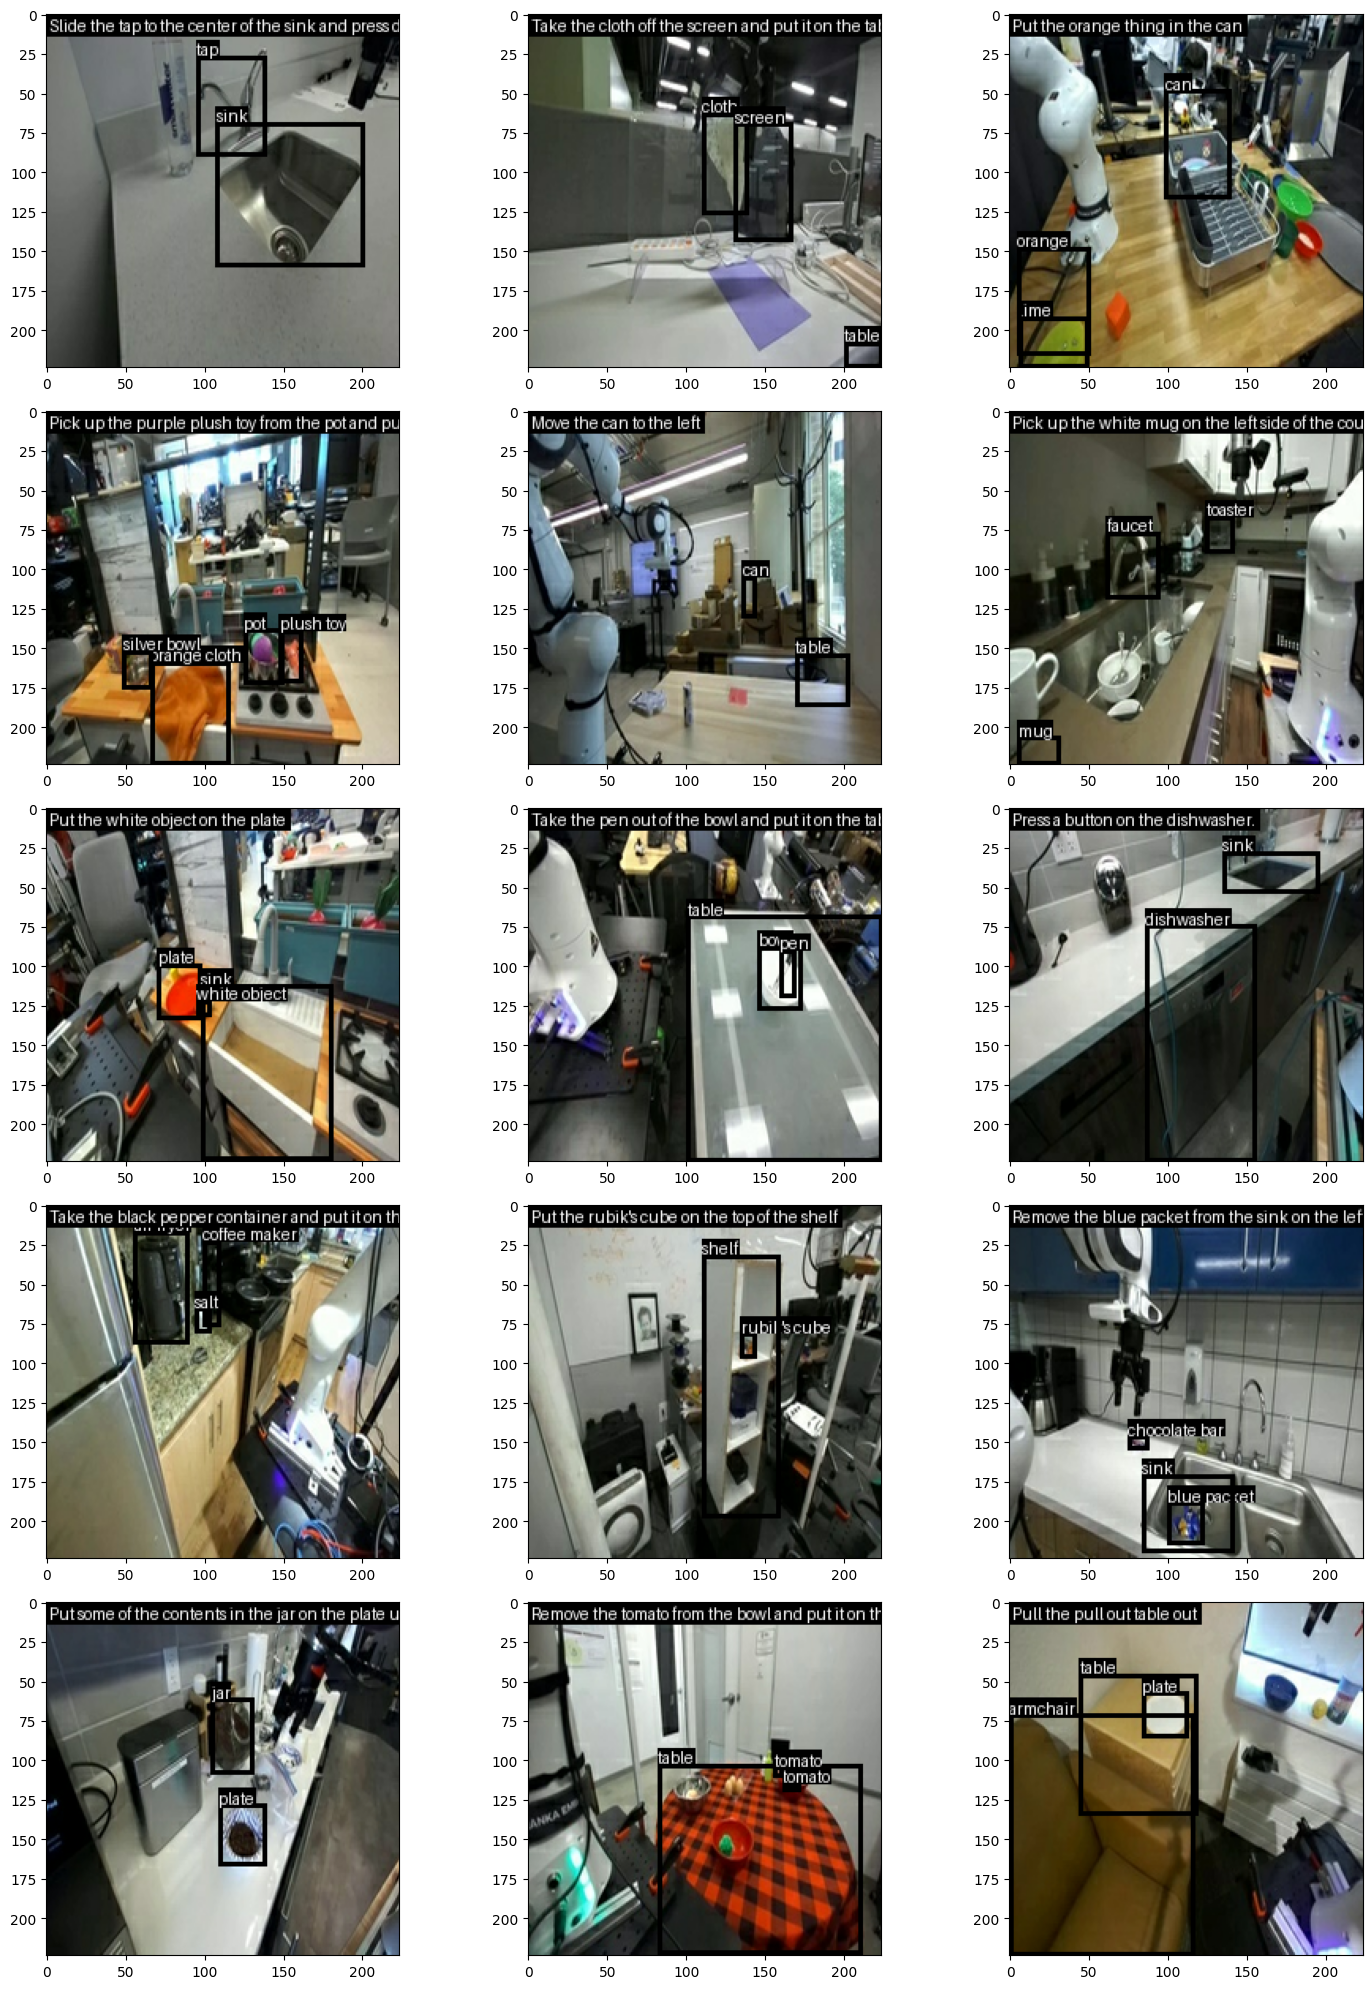

In [60]:
# ... existing code ...
import matplotlib.pyplot as plt


def display_images_grid(images, cols=3):
    """Display images in a grid format."""
    rows = (len(images) + cols - 1) // cols  # Calculate number of rows needed
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()  # Flatten the axes array for easy indexing

    for ax in axes:
        ax.axis('off')  # Hide axes

    for i, img in enumerate(images):
        if i < len(axes):  # Check if there are enough axes
            axes[i].imshow(img)
            axes[i].axis('on')  # Show axes for the images

    plt.tight_layout()
    plt.show()

# Call the function to display the resulting images
display_images_grid(resulting_images)
    

In [10]:
# # trajs = [next(iterator) for _ in range(10)]

# first_images = [traj['observation']['image_primary'][5].squeeze() for traj in trajs]
# language_labels = [traj['task']['language_instruction'][5].decode('utf-8') for traj in trajs]

# for first_image, language_label in zip(first_images, language_labels):
#     if language_label:
#         files = upload_images_to_gemini([first_image])
#         chat_session = model.start_chat(
#             history=[
#                 {
#                 "role": "user",
#                 "parts": files,
#                 },
#             ]
#         )

#         response = chat_session.send_message(f"Please give me the bounding box (box_2d) of the robotic gripper (object_name). Provide both keys in the json dict")
#         print(response.text)
#         print("task: ", language_label)
#         detections = extract_json_from_markdown(response.text)
#         # detections = eval(response.text)
#         plot_detections(detections, first_image) 

#         time.sleep(1)
        
#     else:
#         print("skipping traj bc it's goal conditioned")

